# Cadena de Markov Absorbente - Laberinto del Ratón

En este problema se modela el movimiento aleatorio de un ratón mediante una cadena de Markov absorbente. 
El objetivo es calcular la probabilidad de que el ratón, iniciando en la casilla 0, alcance la comida antes de llegar al estado de shock.

# Modelo Matemático

Los estados del sistema son:

$$
S=\{0,1,2,3,4,5,6,7,8\}
$$

Los estados absorbentes son:

- Estado 7: comida
- Estado 8: shock

Por lo tanto:

$$
P_{7,7}=1
$$

$$
P_{8,8}=1
$$

La matriz de transición se escribe como:

$$
P=
\begin{pmatrix}
Q & R\\
0 & I
\end{pmatrix}
$$

donde:

- $Q$ contiene las transiciones entre estados transitorios.
- $R$ contiene las transiciones hacia estados absorbentes.

La matriz fundamental se define por:

$$
N=(I-Q)^{-1}
$$

y las probabilidades de absorción se calculan mediante:

$$
B=NR
$$

El valor buscado es la probabilidad de llegar a la comida (estado 7) iniciando desde el estado 0.

In [2]:
!pip install sympy

mambajs 0.19.13

Process pip requirements ...



In [3]:
import sympy as sp

In [4]:
import sympy as sp

# Matriz Q
Q = sp.Matrix([

[0,   1/2, 1/2, 0,   0,   0,   0],
[1/3, 0,   0,   1/3, 0,   0,   0],
[1/3, 0,   0,   1/3, 0,   0,   0],
[0,   1/4, 1/4, 0,   1/4, 1/4, 0],
[0,   0,   0,   1/3, 0,   0,   1/3],
[0,   0,   0,   1/3, 0,   0,   1/3],
[0,   0,   0,   0,   1/2, 1/2, 0]

])

# Matriz R
R = sp.Matrix([

[0,   0],
[1/3, 0],
[0,   1/3],
[0,   0],
[1/3, 0],
[0,   1/3],
[0,   0]

])

# Matriz identidad
I = sp.eye(7)

# Matriz fundamental
N = (I - Q).inv()

# Probabilidades de absorción
B = N * R

print("Matriz Fundamental N:\n")
sp.pprint(N)

print("\nProbabilidades de absorción B:\n")
sp.pprint(B)

print("\nProbabilidad de llegar a la comida iniciando desde 0:\n")
print(B[0,0])

Matriz Fundamental N:

[1.75  1.125  1.125  1.0  0.375  0.375  0.25]
[                                           ]
[0.75  1.625  0.625  1.0  0.375  0.375  0.25]
[                                           ]
[0.75  0.625  1.625  1.0  0.375  0.375  0.25]
[                                           ]
[0.5   0.75   0.75   2.0  0.75   0.75   0.5 ]
[                                           ]
[0.25  0.375  0.375  1.0  1.625  0.625  0.75]
[                                           ]
[0.25  0.375  0.375  1.0  0.625  1.625  0.75]
[                                           ]
[0.25  0.375  0.375  1.0  1.125  1.125  1.75]

Probabilidades de absorción B:

[       0.5                0.5       ]
[                                    ]
[0.666666666666667  0.333333333333333]
[                                    ]
[0.333333333333333  0.666666666666667]
[                                    ]
[       0.5                0.5       ]
[                                    ]
[0.666666666666667  0.333333333333

In [5]:
import random

# Función de simulación
def simulacion():

    estado = 0

    while estado not in [7,8]:

        if estado == 0:
            estado = random.choice([1,2])

        elif estado == 1:
            estado = random.choice([0,3,7])

        elif estado == 2:
            estado = random.choice([0,3,8])

        elif estado == 3:
            estado = random.choice([1,2,4,5])

        elif estado == 4:
            estado = random.choice([3,6,7])

        elif estado == 5:
            estado = random.choice([3,6,8])

        elif estado == 6:
            estado = random.choice([4,5])

    return estado

# Número de simulaciones
n = 10000

comida = 0

for i in range(n):

    resultado = simulacion()

    if resultado == 7:
        comida += 1

# Probabilidad experimental
probabilidad = comida / n

print("Probabilidad experimental de llegar a la comida:\n")
print(probabilidad)

Probabilidad experimental de llegar a la comida:

0.4971


# Conclusión

Utilizando cadenas de Markov absorbentes fue posible modelar el movimiento aleatorio del ratón dentro del laberinto.

Mediante la matriz fundamental:

$$
N=(I-Q)^{-1}
$$

se calcularon analíticamente las probabilidades de absorción. Posteriormente, mediante simulación computacional, se obtuvo una aproximación experimental de la probabilidad de alcanzar la comida iniciando desde el estado 0.

Los resultados analíticos y experimentales deben ser similares, validando así el modelo probabilístico desarrollado.

# Cadena de Markov Absorbente - Serpientes y Escaleras

En este problema se modela el juego de serpientes y escaleras mediante una cadena de Markov absorbente.

El objetivo es calcular el número promedio de tiradas necesarias para terminar el juego utilizando matrices y simulación.

# Modelo Matemático

Los estados del juego son:

$$
S=\{1,2,3,\dots,20\}
$$

El estado absorbente es la casilla final:

$$
20
$$

Las transiciones especiales del tablero son:

- Escalera: $3 \to 11$
- Escalera: $15 \to 18$
- Serpiente: $13 \to 5$
- Serpiente: $17 \to 9$

La matriz de transición se escribe como:

$$
P=
\begin{pmatrix}
Q & R\\
0 & I
\end{pmatrix}
$$

donde:

- $Q$ contiene las transiciones entre estados transitorios.
- $R$ contiene las probabilidades de llegar al estado absorbente.

La matriz fundamental se define como:

$$
N=(I-Q)^{-1}
$$

El número esperado de tiradas se calcula mediante:

$$
t=N\mathbf{1}
$$

donde:

$$
\mathbf{1}=
\begin{pmatrix}
1\\
1\\
\vdots\\
1
\end{pmatrix}
$$

El valor buscado es el tiempo esperado iniciando desde la casilla 1.

In [7]:
import sympy as sp

# Número de estados transitorios
n = 19

# Crear matriz Q
Q = sp.zeros(n,n)

# Función para aplicar serpientes y escaleras
def mover(pos):

    if pos == 3:
        return 11

    elif pos == 13:
        return 5

    elif pos == 15:
        return 18

    elif pos == 17:
        return 9

    else:
        return pos

# Construcción de Q
for i in range(1,20):

    for dado in range(1,7):

        nueva = i + dado

        # Si se pasa de 20, permanece en la misma casilla
        if nueva > 20:
            nueva = i

        # Aplicar serpientes y escaleras
        nueva = mover(nueva)

        # Ignorar estado absorbente
        if nueva < 20:
            Q[i-1,nueva-1] += sp.Rational(1,6)

# Matriz identidad
I = sp.eye(n)

# Matriz fundamental
N = (I - Q).inv()

# Vector columna de unos
unos = sp.ones(n,1)

# Tiempos esperados
t = N * unos

print("Número esperado de tiradas desde cada estado:\n")
sp.pprint(t)

print("\nNúmero promedio de tiradas iniciando desde la casilla 1:\n")
print(float(t[0]))

Número esperado de tiradas desde cada estado:

[1580455367]
[----------]
[138342420 ]
[          ]
[ 13593983 ]
[ -------- ]
[ 1213530  ]
[          ]
[ 51891193 ]
[ -------- ]
[ 4611414  ]
[          ]
[ 8396881  ]
[ -------  ]
[ 768569   ]
[          ]
[ 40933764 ]
[ -------- ]
[ 3842845  ]
[          ]
[ 39797034 ]
[ -------- ]
[ 3842845  ]
[          ]
[ 39959424 ]
[ -------- ]
[ 3842845  ]
[          ]
[ 37924062 ]
[ -------- ]
[ 3842845  ]
[          ]
[ 35800206 ]
[ -------- ]
[ 3842845  ]
[          ]
[ 6886974  ]
[ -------  ]
[ 768569   ]
[          ]
[ 34629918 ]
[ -------- ]
[ 3842845  ]
[          ]
[ 32976654 ]
[ -------- ]
[ 3842845  ]
[          ]
[ 5999441  ]
[ -------  ]
[ 768569   ]
[          ]
[ 5142378  ]
[ -------  ]
[ 768569   ]
[          ]
[ 5142378  ]
[ -------  ]
[ 768569   ]
[          ]
[ 26242854 ]
[ -------- ]
[ 3842845  ]
[          ]
[ 29428638 ]
[ -------- ]
[ 3842845  ]
[          ]
[    6     ]
[          ]
[    6     ]

Número promedio de tiradas in

In [8]:
import random
import numpy as np

# Función de simulación
def juego():

    posicion = 1
    tiradas = 0

    while posicion != 20:

        dado = random.randint(1,6)

        nueva = posicion + dado

        # Si se pasa, permanece igual
        if nueva > 20:
            nueva = posicion

        # Serpientes y escaleras
        if nueva == 3:
            nueva = 11

        elif nueva == 13:
            nueva = 5

        elif nueva == 15:
            nueva = 18

        elif nueva == 17:
            nueva = 9

        posicion = nueva

        tiradas += 1

    return tiradas

# Número de simulaciones
m = 10000

resultados = []

for i in range(m):

    resultados.append(juego())

# Promedio experimental
promedio = np.mean(resultados)

print("Número promedio de tiradas por simulación:\n")
print(promedio)

Número promedio de tiradas por simulación:

11.3693


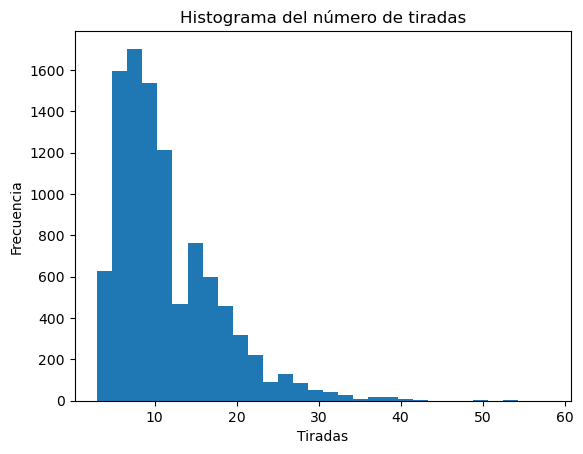

In [11]:
import matplotlib.pyplot as plt

plt.hist(resultados, bins=30)

plt.title("Histograma del número de tiradas")
plt.xlabel("Tiradas")
plt.ylabel("Frecuencia")

plt.show()

# Conclusión

El juego de serpientes y escaleras puede modelarse mediante una cadena de Markov absorbente.

Usando la matriz fundamental:

$$
N=(I-Q)^{-1}
$$

fue posible calcular analíticamente el número esperado de tiradas necesarias para terminar el juego.

Posteriormente, mediante simulación computacional, se obtuvo una aproximación experimental del mismo valor.

Los resultados analíticos y experimentales deben ser similares, validando el modelo probabilístico desarrollado.